#### 1-Load data and Visualization

In [ ]:
import numpy as np
import struct

def read_images(filename):
    with open(filename, 'rb') as f:
        _, num_images, rows, cols = struct.unpack('>IIII', f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8)
        data = data.reshape(num_images, rows, cols)
    return data

def read_labels(filename):
    with open(filename, 'rb') as f:
        _, num_items = struct.unpack('>II', f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

train_images = read_images("./Dataset/train-images-idx3-ubyte")
train_labels = read_labels("./Dataset/train-labels-idx1-ubyte")
test_images  = read_images("./Dataset/t10k-images-idx3-ubyte")
test_labels  = read_labels("./Dataset/t10k-labels-idx1-ubyte")

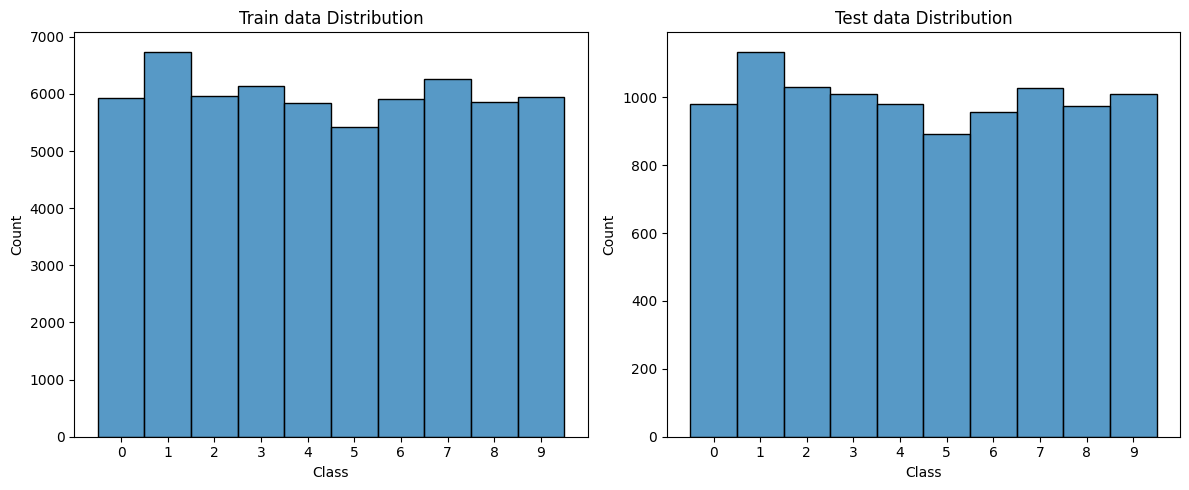

Shape of original train images: (60000, 28, 28)
Shape of processed train images: (60000, 784)
Shape of original test images: (10000, 28, 28)
Shape of processed test images: (10000, 784)


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(train_labels, kde=False, bins=np.arange(0, 11) - 0.5)
plt.title('Train data Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(range(10))

plt.subplot(1, 2, 2)
sns.histplot(test_labels, kde=False, bins=np.arange(0, 11) - 0.5)
plt.title('Test data Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(range(10))

plt.tight_layout()
plt.show()

def preprocess_data(images, labels):
    images = images.reshape(images.shape[0], -1) / 255.0
    return images, labels

train_images_processed, train_labels_processed = preprocess_data(train_images, train_labels)
test_images_processed, test_labels_processed = preprocess_data(test_images, test_labels)

print("Shape of original train images:", train_images.shape)
print("Shape of processed train images:", train_images_processed.shape)
print("Shape of original test images:", test_images.shape)
print("Shape of processed test images:", test_images_processed.shape)


#### 2-Implement AutoEncoders

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Convert numpy arrays to torch tensors
train_images_tensor = torch.tensor(train_images_processed, dtype=torch.float32).to(device)
train_labels_tensor = torch.tensor(train_labels_processed, dtype=torch.long).to(device)
test_images_tensor = torch.tensor(test_images_processed, dtype=torch.float32).to(device)
test_labels_tensor = torch.tensor(test_labels_processed, dtype=torch.long).to(device)

batch_size = 256

train_dataset = TensorDataset(train_images_tensor, train_images_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(test_images_tensor, test_images_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Using device: mps


In [28]:

# Model 1: 8 neuron output encoder
class Autoencoder1(nn.Module):
    def __init__(self):
        super(Autoencoder1, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(True),
            nn.Linear(128, 8),
            nn.ReLU(True)
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 128),
            nn.ReLU(True),
            nn.Linear(128, 784),
            nn.ReLU(True)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded




# Model 2: 4 neuron output encoder
class Autoencoder2(nn.Module):
    def __init__(self):
        super(Autoencoder2, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(True),
            nn.Linear(128, 4),
            nn.ReLU(True)
        )
        self.decoder = nn.Sequential(
            nn.Linear(4, 128),
            nn.ReLU(True),
            nn.Linear(128, 784),
            nn.ReLU(True) 
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


# Training function
def train_model(model, train_loader, criterion, optimizer, epochs, model_name):
    print(f"Training {model_name}...")
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_idx, (data, _) in enumerate(train_loader): # Unpack data, ignore target as it's the same
            data = data.to(device)
            # Forward pass
            outputs = model(data)
            loss = criterion(outputs, data) # Reconstruct the input data

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        if (epoch+1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}')
    print(f"{model_name} training finished.")


def evaluate_model(model, test_loader, criterion, model_name):
    print(f"Evaluating {model_name}...")
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for data, _ in test_loader:
            data = data.to(device)
            outputs = model(data)
            loss = criterion(outputs, data)
            total_loss += loss.item() * data.size(0)
    avg_loss = total_loss / len(test_loader.dataset)
    print(f'{model_name} Test Reconstruction Loss: {avg_loss:.6f}')
    return avg_loss

#### 3-Train AutoEncoders

In [ ]:
# Training parameters
num_epochs = 50

model1 = Autoencoder1().to(device)
model2 = Autoencoder2().to(device)

criterion = nn.MSELoss()

optimizer1 = optim.Adam(model1.parameters(), lr=0.001)
optimizer2 = optim.Adam(model2.parameters(), lr=0.001)

train_model(model1, train_loader, criterion, optimizer1, num_epochs, "Autoencoder 1 (8 neurons)")
train_model(model2, train_loader, criterion, optimizer2, num_epochs, "Autoencoder 2 (4 neurons)")

test_loss1 = evaluate_model(model1, test_loader, criterion, "Autoencoder 1 (8 neurons)")
test_loss2 = evaluate_model(model2, test_loader, criterion, "Autoencoder 2 (4 neurons)")

Training Autoencoder 1 (8 neurons)...
Epoch [10/50], Loss: 0.030086
Epoch [20/50], Loss: 0.028597
Epoch [30/50], Loss: 0.027651
Epoch [40/50], Loss: 0.026833
Epoch [50/50], Loss: 0.026565
Autoencoder 1 (8 neurons) training finished.
Training Autoencoder 2 (4 neurons)...
Epoch [10/50], Loss: 0.045883
Epoch [20/50], Loss: 0.043361
Epoch [30/50], Loss: 0.042671
Epoch [40/50], Loss: 0.042026
Epoch [50/50], Loss: 0.041664
Autoencoder 2 (4 neurons) training finished.
Evaluating Autoencoder 1 (8 neurons)...
Autoencoder 1 (8 neurons) Test Reconstruction Loss: 0.026858
Evaluating Autoencoder 2 (4 neurons)...
Autoencoder 2 (4 neurons) Test Reconstruction Loss: 0.042628


#### 4- 